In [3]:
!pip install transformers torch torchvision pillow datasets

In [2]:
import torch, math
from torch.utils.data import DataLoader
from torchvision import transforms
from transformers import AutoImageProcessor, ViTMAEForPreTraining

from transformers import AutoImageProcessor
from PIL import Image
import numpy as np

# Preprocesamiento

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
import shutil
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm

# 1. Definir rutas base
base_path = '/content/drive/MyDrive/ProyectoDL'

# Fuentes de datos
source_sanos = os.path.join(base_path, 'Imagenes sanos')
source_stages = os.path.join(base_path, 'Imagenes')
source_dataset = os.path.join(base_path, 'Dataset')

# Ruta de destino
dest_folder = os.path.join(base_path, 'dataset_unificado')
dest_images = os.path.join(dest_folder, 'images')

print("--- Iniciando: Estandarización (Eliminando Doppler/Color) ---")

# Limpieza inicial
if os.path.exists(dest_folder):
    print(f"Eliminando carpeta previa: {dest_folder}")
    shutil.rmtree(dest_folder)

os.makedirs(dest_images, exist_ok=True)

data = []
valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def analyze_and_process(src_path, dst_path):
    """
    1. Analiza la imagen original.
    2. Elimina color (Doppler) pasando a Grayscale.
    3. Estandariza a 3 canales (RGB) para el modelo.
    """
    try:
        with Image.open(src_path) as img:
            # --- ANÁLISIS (Sobre la original) ---
            bands = img.getbands()
            original_channels = len(bands)
            has_irrigation = False

            # Detección de Riego original (solo para estadística)
            if original_channels >= 3:
                img_small = img.resize((50, 50))
                arr = np.array(img_small.convert('RGB')).astype(float)
                r, g, b = arr[:,:,0], arr[:,:,1], arr[:,:,2]
                diff = np.mean(np.abs(r - g)) + np.mean(np.abs(g - b))
                if diff > 5.0:
                    has_irrigation = True

            # --- PROCESAMIENTO: QUITAR DOPPLER Y ESTANDARIZAR ---

            # 1. Convertir a Escala de Grises ('L')
            # Esto ELIMINA la información de color (Doppler rojo/azul desaparece)
            img_gray = img.convert('L')

            # 2. Convertir a RGB
            # Replica el canal gris en R, G y B.
            # Resultado: Imagen visualmente gris, pero técnicamente con 3 canales.
            img_final = img_gray.convert('RGB')

            # Guardamos con alta calidad
            img_final.save(dst_path, quality=95)

            return original_channels, has_irrigation

    except Exception as e:
        print(f"Error procesando {os.path.basename(src_path)}: {e}")
        return None, None

def process_recursively(root_folder, label_name, source_prefix):
    count = 0
    for current_root, dirs, files in os.walk(root_folder):
        img_files = [f for f in files if f.lower().endswith(valid_exts)]

        for img_name in img_files:
            src_path = os.path.join(current_root, img_name)

            unique_id = len(data)
            new_name = f"{source_prefix}_{label_name}_{unique_id}_{img_name}"
            dst_path = os.path.join(dest_images, new_name)

            # Procesar
            orig_channels, irrigation = analyze_and_process(src_path, dst_path)

            if orig_channels is not None:
                data.append({
                    'filename': new_name,
                    'label': label_name,
                    'source': source_prefix,
                    'original_path': src_path,
                    'original_channels': orig_channels,
                    'processed_channels': 3,            # Todas quedan en 3
                    'doppler_removed': True,            # Flag informativo
                    'original_had_doppler': irrigation  # Para saber cuáles tenían color
                })
                count += 1
    return count

# --- EJECUCIÓN ---

# 1. Sanos
if os.path.exists(source_sanos):
    n = process_recursively(source_sanos, 'F0', 'sanos')
    print(f"[Sanos] Procesadas: {n}")

# 2. Etapas
subfolders = ['F0', 'F1', 'F2', 'F3', 'F4']

def process_stage_folder(base_stage_path, prefix_name):
    if os.path.exists(base_stage_path):
        print(f"[{prefix_name}] Procesando carpetas...")
        for folder in subfolders:
            folder_path = os.path.join(base_stage_path, folder)
            if os.path.exists(folder_path):
                process_recursively(folder_path, folder, prefix_name)

process_stage_folder(source_stages, 'old_stages')
process_stage_folder(source_dataset, 'new_dataset')

# 3. Guardar CSV
df = pd.DataFrame(data)

if not df.empty:
    csv_path = os.path.join(dest_folder, 'metadata.csv')
    df.to_csv(csv_path, index=False)

    print("\n--- Proceso Finalizado ---")
    print(f"Total de imágenes: {len(df)}")
    print("Todas las imágenes han sido convertidas a Grayscale -> RGB (Sin Doppler).")

    print("\nResumen de detección original de Doppler (Color):")
    print(df.groupby(['label', 'original_had_doppler']).size())
else:
    print("Error: No se encontraron imágenes.")

--- Iniciando: Estandarización (Eliminando Doppler/Color) ---
[Sanos] Procesadas: 322
[old_stages] Procesando carpetas...
[new_dataset] Procesando carpetas...

--- Proceso Finalizado ---
Total de imágenes: 7579
Todas las imágenes han sido convertidas a Grayscale -> RGB (Sin Doppler).

Resumen de detección original de Doppler (Color):
label  original_had_doppler
F0     False                   2461
       True                      33
F1     False                   1035
       True                      73
F2     False                    842
       True                      14
F3     False                    943
       True                      70
F4     False                   1922
       True                     186
dtype: int64


In [6]:
data = pd.read_csv('/content/drive/MyDrive/ProyectoDL/dataset_unificado/metadata.csv')
data.head(5)

,filename,label,source,original_path,original_channels,processed_channels,doppler_removed,original_had_doppler
0,sanos_F0_0_IM-0001-0013.jpg,F0,sanos,/content/drive/MyDrive/ProyectoDL/Imagenes san...,3,3,True,False
1,sanos_F0_1_IM-0001-0005.jpg,F0,sanos,/content/drive/MyDrive/ProyectoDL/Imagenes san...,3,3,True,False
2,sanos_F0_2_IM-0001-0004.jpg,F0,sanos,/content/drive/MyDrive/ProyectoDL/Imagenes san...,3,3,True,False
3,sanos_F0_3_IM-0001-0003.jpg,F0,sanos,/content/drive/MyDrive/ProyectoDL/Imagenes san...,3,3,True,False
4,sanos_F0_4_IM-0001-0001.jpg,F0,sanos,/content/drive/MyDrive/ProyectoDL/Imagenes san...,3,3,True,False


In [7]:
data.label.value_counts()

,count
label,
F0,2494
F4,2108
F1,1108
F3,1013
F2,856


# Modelo

In [8]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import os
import pandas as pd
from PIL import Image

## Donde están los datos

In [9]:
# Paths (ajusta si cambian)
base_path = '/content/drive/MyDrive/ProyectoDL'
metadata_path = os.path.join(base_path, 'dataset_unificado', 'metadata.csv')
images_dir = os.path.join(base_path, 'dataset_unificado', 'images')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


## División Train, Val, Test 80/10/10

In [10]:
datos = pd.read_csv(metadata_path)

label2idx = {'F0': 0, 'F1': 1, 'F2': 2, 'F3': 3, 'F4': 4}
idx2label = {k: v for k, v in label2idx.items()}
datos['label_id'] = datos['label'].map(label2idx)

print("Total de imágenes en metadata:", len(datos))
print(datos['label'].value_counts())

# 2. Train / Test split (80% / 20%) estratificado
train_df, test_df = train_test_split(
    datos,
    test_size=0.2,
    stratify=datos['label'],
    random_state=42
)

# 3. Split Train / Val (80% del 80% para train, 20% para val → 64/16/20)
test_df, val_df = train_test_split(
    test_df,
    test_size=0.5,
    stratify=test_df['label'],
    random_state=42
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Train dist:\n", train_df['label'].value_counts())
print("Val dist:\n", val_df['label'].value_counts())
print("Test dist:\n", test_df['label'].value_counts())

Total de imágenes en metadata: 7579
label
F0    2494
F4    2108
F1    1108
F3    1013
F2     856
Name: count, dtype: int64
Train: 6063 Val: 758 Test: 758
Train dist:
 label
F0    1995
F4    1686
F1     886
F3     811
F2     685
Name: count, dtype: int64
Val dist:
 label
F0    250
F4    211
F1    111
F3    101
F2     85
Name: count, dtype: int64
Test dist:
 label
F0    249
F4    211
F1    111
F3    101
F2     86
Name: count, dtype: int64


In [11]:
train_df.head(5)

,filename,label,source,original_path,original_channels,processed_channels,doppler_removed,original_had_doppler,label_id
6329,new_dataset_F4_6329_g16.jpg,F4,new_dataset,/content/drive/MyDrive/ProyectoDL/Dataset/F4/g...,1,3,True,False,4
3461,new_dataset_F1_3461_E9281.jpg,F1,new_dataset,/content/drive/MyDrive/ProyectoDL/Dataset/F1/E...,3,3,True,False,1
5591,new_dataset_F3_5591_ct9-27.png,F3,new_dataset,/content/drive/MyDrive/ProyectoDL/Dataset/F3/c...,3,3,True,False,3
1513,new_dataset_F0_1513_a7405.jpg,F0,new_dataset,/content/drive/MyDrive/ProyectoDL/Dataset/F0/a...,1,3,True,False,0
5490,new_dataset_F3_5490_ct10-69.png,F3,new_dataset,/content/drive/MyDrive/ProyectoDL/Dataset/F3/c...,3,3,True,False,3


## Creación de los dataloaders

In [12]:
class LiverFibrosisDataset(Dataset):
    def __init__(self, df, images_dir, image_processor):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.processor = image_processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['filename'])

        # Abrir imagen
        image = Image.open(img_path).convert("RGB")

        # Procesar con el image processor de ViT-MAE
        encoded = self.processor(image, return_tensors="pt")

        # pixel_values: [1, 3, H, W] → quitamos dim 0
        pixel_values = encoded["pixel_values"].squeeze(0)

        label = int(row['label_id'])

        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(label, dtype=torch.long)
        }


In [13]:
from transformers import AutoImageProcessor, ViTMAEForPreTraining

model_name = "facebook/vit-mae-base"
image_processor = AutoImageProcessor.from_pretrained(model_name)

preprocessor_config.json:   0%|          | 0.00/217 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/676 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [14]:
train_dataset = LiverFibrosisDataset(train_df, images_dir, image_processor)
test_dataset  = LiverFibrosisDataset(test_df,  images_dir, image_processor)
val_dataset   = LiverFibrosisDataset(val_df,   images_dir, image_processor)

batch_size = 32  # ajusta según VRAM

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=1)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=1)

In [15]:
len(train_loader)*batch_size

6080

## Creación del modelo de MAE

In [16]:
mae = ViTMAEForPreTraining.from_pretrained("facebook/vit-mae-base")

model.safetensors:   0%|          | 0.00/448M [00:00<?, ?B/s]

In [17]:
mae

ViTMAEForPreTraining(
  (vit): ViTMAEModel(
    (embeddings): ViTMAEEmbeddings(
      (patch_embeddings): ViTMAEPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
    )
    (encoder): ViTMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTMAELayer(
          (attention): ViTMAEAttention(
            (attention): ViTMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_fn): GELUActivat

In [ ]:
save_dir = "/content/drive/MyDrive/ProyectoDL/modelos"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
from torch.optim import AdamW
from tqdm.auto import tqdm

optimizer = AdamW(mae.parameters(), lr=1e-4)
num_epochs = 100
mae.to(device)

best_val_loss = float("inf")   # <<< valor inicial gigante para comparar
best_epoch = -1

print("Iniciando entrenamiento (Pre-training MAE)...")

for epoch in range(num_epochs):
    # --- TRAINING ---
    mae.train()
    total_train_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for batch in progress_bar:
        pixel_values = batch["pixel_values"].to(device)

        outputs = mae(pixel_values=pixel_values)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        progress_bar.set_postfix({'train_loss': loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)

    # --- VALIDATION ---
    mae.eval()
    total_val_loss = 0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
        for batch in val_bar:
            pixel_values = batch["pixel_values"].to(device)
            outputs = mae(pixel_values=pixel_values)
            loss = outputs.loss
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- CHECKPOINT: Guardar solo si mejoró ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1

        output_path = os.path.join(save_dir, f"best_mae_epoch_{best_epoch}")
        mae.save_pretrained(output_path)

        print(f"💾 Nuevo mejor modelo guardado (epoch {best_epoch}) con val_loss = {best_val_loss:.4f}")

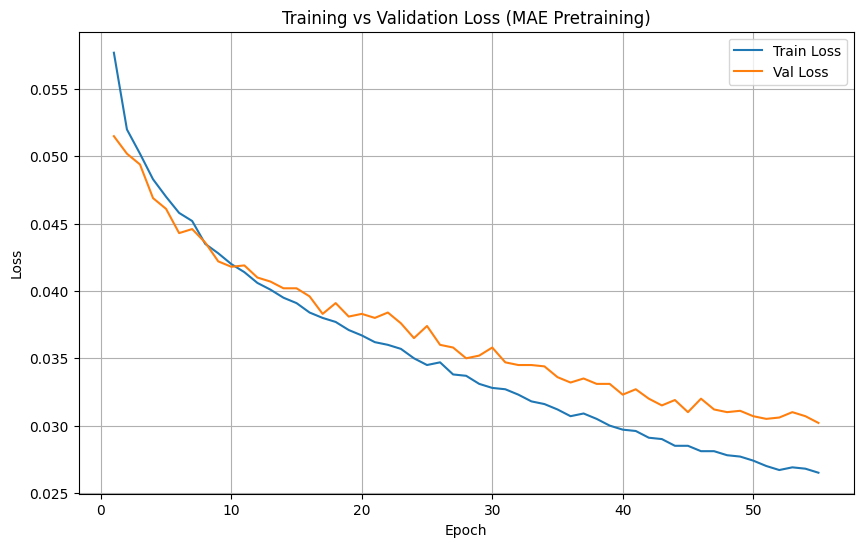

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
datos = pd.read_csv("/content/losses.csv")  # recuerda que usas 'datos' 😉

# === Graficar ===
plt.figure(figsize=(10,6))
plt.plot(datos["epoch"], datos["train_loss"], label="Train Loss")
plt.plot(datos["epoch"], datos["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (MAE Pretraining)")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
class ViTMAEForFibrosisClassification(nn.Module):
    def __init__(self, num_labels, encoder):
        super().__init__()
        self.encoder = encoder

        hidden_size = self.encoder.config.hidden_size  # 768 en vit-base

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_labels)
        )

    def forward(self, pixel_values, labels=None):
        outputs = self.encoder(pixel_values=pixel_values)
        last_hidden = outputs.last_hidden_state

        cls_token = last_hidden[:, 0, :]

        logits = self.classifier(cls_token) # Estos son los logits

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        probabilities = torch.softmax(logits, dim=-1)

        return {"loss": loss, "logits": logits, "probabilities": probabilities}

In [19]:
mae = ViTMAEForPreTraining.from_pretrained('/content/drive/MyDrive/ProyectoDL/modelos/best_mae_epoch_55')

vit_mae = mae.vit
vit_mae.encoder.mask_ratio = 0.0
vit_mae.to(device)

ViTMAEModel(
  (embeddings): ViTMAEEmbeddings(
    (patch_embeddings): ViTMAEPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
  )
  (encoder): ViTMAEEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTMAELayer(
        (attention): ViTMAEAttention(
          (attention): ViTMAESelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTMAESelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTMAEIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTMAEOutput(
          (dense): Linear(i

In [20]:
vit_classifier = ViTMAEForFibrosisClassification(num_labels=5, encoder=vit_mae)
vit_classifier.to(device)

ViTMAEForFibrosisClassification(
  (encoder): ViTMAEModel(
    (embeddings): ViTMAEEmbeddings(
      (patch_embeddings): ViTMAEPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
    )
    (encoder): ViTMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTMAELayer(
          (attention): ViTMAEAttention(
            (attention): ViTMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_f

In [21]:
save_dir = "/content/drive/MyDrive/ProyectoDL/modelos_clasificación"
os.makedirs(save_dir, exist_ok=True)

In [22]:
from torch.optim import AdamW
from tqdm.auto import tqdm
import pandas as pd

# Definir el optimizador para el clasificador
optimizer = AdamW(vit_classifier.parameters(), lr=5e-5) # Una LR menor para fine-tuning
num_epochs = 50 # Número de epochs para fine-tuning

vit_classifier.to(device)

best_val_loss = float("inf")
best_epoch = -1

# Lista para guardar las pérdidas
loss_history = []

print("Iniciando fine-tuning (Clasificación de Fibrosis)...")

for epoch in range(num_epochs):
    # --- TRAINING ---
    vit_classifier.train()
    total_train_loss = 0
    total_train_correct_predictions = 0
    total_train_samples = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for batch in progress_bar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = vit_classifier(pixel_values=pixel_values, labels=labels)
        loss = outputs["loss"]
        logits = outputs["logits"]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        predictions = logits.argmax(dim=1)
        correct_predictions = (predictions == labels).sum().item()
        total_train_correct_predictions += correct_predictions
        total_train_samples += labels.size(0)

        batch_accuracy = correct_predictions / labels.size(0)
        progress_bar.set_postfix({'train_loss': loss.item(), 'train_acc': f'{batch_accuracy:.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_accuracy = total_train_correct_predictions / total_train_samples if total_train_samples > 0 else 0

    # --- VALIDATION ---
    vit_classifier.eval()
    total_val_loss = 0
    total_val_correct_predictions = 0
    total_val_samples = 0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
        for batch in val_bar:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = vit_classifier(pixel_values=pixel_values, labels=labels)
            loss = outputs["loss"]
            logits = outputs["logits"]

            total_val_loss += loss.item()

            predictions = logits.argmax(dim=1)
            correct_predictions = (predictions == labels).sum().item()
            total_val_correct_predictions += correct_predictions
            total_val_samples += labels.size(0)

            batch_accuracy = correct_predictions / labels.size(0)
            val_bar.set_postfix({'val_loss': loss.item(), 'val_acc': f'{batch_accuracy:.4f}'})

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_correct_predictions / total_val_samples if total_val_samples > 0 else 0

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")

    # Guardar historial de pérdidas y accuracy
    loss_history.append({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "train_accuracy": avg_train_accuracy,
        "val_loss": avg_val_loss,
        "val_accuracy": avg_val_accuracy
    })

    # --- CHECKPOINT: Guardar solo si mejoró ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1

        output_path = os.path.join(save_dir, f"best_vit_classifier_epoch_{best_epoch}")
        os.makedirs(output_path, exist_ok=True)
        # Guardar el estado completo del modelo (incluyendo el encoder y el clasificador)
        torch.save(vit_classifier.state_dict(), os.path.join(output_path, 'vit_classifier.pth'))
        # Si el encoder es de HuggingFace, también se podría guardar su estado por separado si se desea mantener su estructura
        # vit_mae.save_pretrained(output_path) # Esto guarda el ViTMAEModel que es el encoder

        print(f"💾 Nuevo mejor modelo guardado (epoch {best_epoch}) con val_loss = {best_val_loss:.4f}")

# Guardar el historial de pérdidas en un CSV
loss_df = pd.DataFrame(loss_history)
loss_df.to_csv(os.path.join(save_dir, 'fine_tuning_losses.csv'), index=False)
print(f"Historial de pérdidas guardado en {os.path.join(save_dir, 'fine_tuning_losses.csv')}")

print("Fine-tuning completado.")

Iniciando fine-tuning (Clasificación de Fibrosis)...


Epoch 1/50 [Train]:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.0030 | Train Acc: 0.5868 | Val Loss: 0.7142 | Val Acc: 0.6900
💾 Nuevo mejor modelo guardado (epoch 1) con val_loss = 0.7142


Epoch 2/50 [Train]:   0%|          | 0/190 [00:00<?, ?it/s]

...

Epoch 49/50 [Val]:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 49 | Train Loss: 0.0275 | Train Acc: 0.9901 | Val Loss: 0.1561 | Val Acc: 0.9578


Epoch 50/50 [Train]:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 50 | Train Loss: 0.0313 | Train Acc: 0.9899 | Val Loss: 0.1699 | Val Acc: 0.9591
Historial de pérdidas guardado en /content/drive/MyDrive/ProyectoDL/modelos_clasificación/fine_tuning_losses.csv
Fine-tuning completado.


In [23]:
data_entrenamiento = pd.read_csv('/content/drive/MyDrive/ProyectoDL/modelos_clasificación/fine_tuning_losses.csv')
data_entrenamiento.head(5)

,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,1.002970,0.586838,0.714192,0.689974
1,2,0.615500,0.750124,0.492292,0.807388
2,3,0.458971,0.815933,0.434573,0.825858
3,4,0.341164,0.868712,0.373393,0.857520
4,5,0.264346,0.901534,0.342555,0.883905


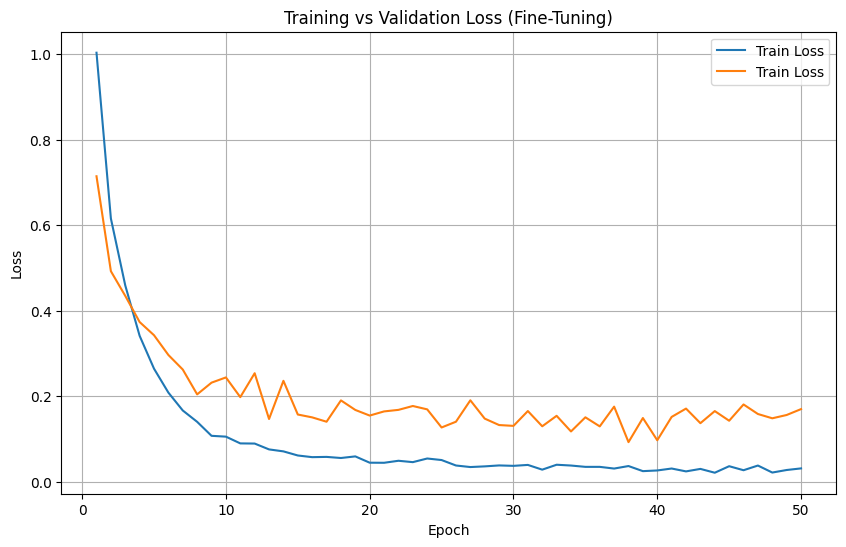

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(data_entrenamiento["epoch"], data_entrenamiento["train_loss"], label="Train Loss")
plt.plot(data_entrenamiento["epoch"], data_entrenamiento["val_loss"], label="Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Fine-Tuning)")
plt.legend()
plt.grid(True)
plt.show()

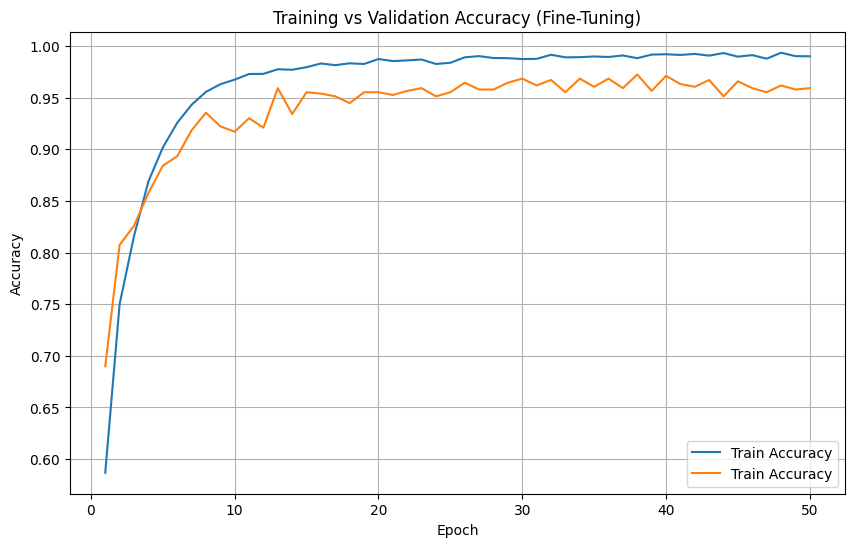

In [26]:
plt.figure(figsize=(10,6))
plt.plot(data_entrenamiento["epoch"], data_entrenamiento["train_accuracy"], label="Train Accuracy")
plt.plot(data_entrenamiento["epoch"], data_entrenamiento["val_accuracy"], label="Train Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Fine-Tuning)")
plt.legend()
plt.grid(True)
plt.show()


In [27]:
model_path = '/content/drive/MyDrive/ProyectoDL/modelos_clasificación/best_vit_classifier_epoch_38/vit_classifier.pth'

model = ViTMAEForFibrosisClassification(num_labels=5, encoder=vit_mae)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

ViTMAEForFibrosisClassification(
  (encoder): ViTMAEModel(
    (embeddings): ViTMAEEmbeddings(
      (patch_embeddings): ViTMAEPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
    )
    (encoder): ViTMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTMAELayer(
          (attention): ViTMAEAttention(
            (attention): ViTMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_f

In [ ]:
!pip install onnx

In [31]:
save_dir = "/content/drive/MyDrive/ProyectoDL/modelos_para_prod"
os.makedirs(save_dir, exist_ok=True)

In [32]:
dummy = torch.randn(1, 3, 224, 224).to(device)
torch.onnx.export(
    model,
    dummy,
    "/content/drive/MyDrive/ProyectoDL/modelos_para_prod/5_clases.onnx",
    input_names=["pixel_values"],
    output_names=["logits"],
    dynamic_axes={
        "pixel_values": {0: "batch_size"},
        "logits": {0: "batch_size"}
    },
    opset_version=17
)


/tmp/ipython-input-2672441261.py:2: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


# Evaluación del modelo sobre testing

In [33]:
def get_predictions(model, dataloader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluando modelo"):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            logits = outputs["logits"]

            preds = torch.argmax(logits, dim=-1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_preds, all_labels

In [34]:
preds, y_true = get_predictions(model, test_loader)

Evaluando modelo:   0%|          | 0/24 [00:00<?, ?it/s]

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_true, preds, target_names=["F0","F1","F2","F3","F4"]))

              precision    recall  f1-score   support

          F0       0.98      0.99      0.99       249
          F1       0.93      0.94      0.93       111
          F2       0.85      0.92      0.88        86
          F3       0.98      0.90      0.94       101
          F4       1.00      0.99      0.99       211

    accuracy                           0.96       758
   macro avg       0.95      0.95      0.95       758
weighted avg       0.96      0.96      0.96       758



In [36]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_true, preds)
print(f"Accuracy total: {acc:.4f}")

Accuracy total: 0.9617


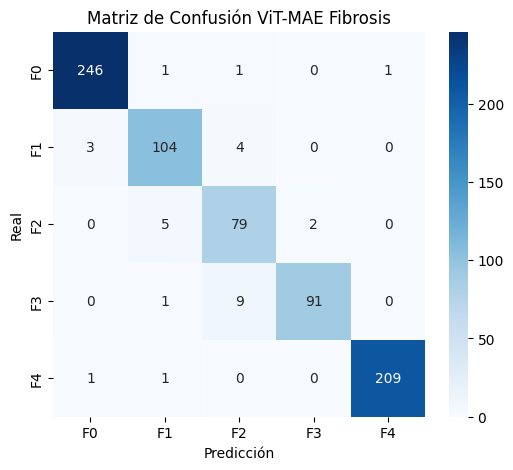

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=["F0","F1","F2","F3","F4"],
            yticklabels=["F0","F1","F2","F3","F4"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión ViT-MAE Fibrosis")
plt.show()

# Probemos lo mismo, pero con solo 3 clases, sano, fibrosis, cirrosis

In [38]:
datos = pd.read_csv(metadata_path)

label2idx = {'F0': 0, 'F1': 1, 'F2': 1, 'F3': 1, 'F4': 2}
idx2label = {k: v for k, v in label2idx.items()}
datos['label_id'] = datos['label'].map(label2idx)

print("Total de imágenes en metadata:", len(datos))
print(datos['label'].value_counts())

# 2. Train / Test split (80% / 20%) estratificado
train_df, test_df = train_test_split(
    datos,
    test_size=0.2,
    stratify=datos['label'],
    random_state=42
)

# 3. Split Train / Val (80% del 80% para train, 20% para val → 64/16/20)
test_df, val_df = train_test_split(
    test_df,
    test_size=0.5,
    stratify=test_df['label'],
    random_state=42
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Train dist:\n", train_df['label_id'].value_counts())
print("Val dist:\n", val_df['label_id'].value_counts())
print("Test dist:\n", test_df['label_id'].value_counts())

Total de imágenes en metadata: 7579
label
F0    2494
F4    2108
F1    1108
F3    1013
F2     856
Name: count, dtype: int64
Train: 6063 Val: 758 Test: 758
Train dist:
 label_id
1    2382
0    1995
2    1686
Name: count, dtype: int64
Val dist:
 label_id
1    297
0    250
2    211
Name: count, dtype: int64
Test dist:
 label_id
1    298
0    249
2    211
Name: count, dtype: int64


In [39]:
train_dataset = LiverFibrosisDataset(train_df, images_dir, image_processor)
test_dataset  = LiverFibrosisDataset(test_df,  images_dir, image_processor)
val_dataset   = LiverFibrosisDataset(val_df,   images_dir, image_processor)

batch_size = 32  # ajusta según VRAM

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=1)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=1)

In [40]:
mae_3_classes = ViTMAEForPreTraining.from_pretrained('/content/drive/MyDrive/ProyectoDL/modelos/best_mae_epoch_55')
vit_mae_3_classes = mae.vit

vit_mae_3_classes.encoder.mask_ratio = 0.0

vit_mae_3_classes.to(device)

ViTMAEModel(
  (embeddings): ViTMAEEmbeddings(
    (patch_embeddings): ViTMAEPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
  )
  (encoder): ViTMAEEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTMAELayer(
        (attention): ViTMAEAttention(
          (attention): ViTMAESelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTMAESelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTMAEIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTMAEOutput(
          (dense): Linear(i

In [41]:
vit_classifier = ViTMAEForFibrosisClassification(num_labels=3, encoder=vit_mae_3_classes)
vit_classifier.to(device)

ViTMAEForFibrosisClassification(
  (encoder): ViTMAEModel(
    (embeddings): ViTMAEEmbeddings(
      (patch_embeddings): ViTMAEPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
    )
    (encoder): ViTMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTMAELayer(
          (attention): ViTMAEAttention(
            (attention): ViTMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_f

In [42]:
save_dir = "/content/drive/MyDrive/ProyectoDL/modelos_clasificacion_3_clases"
os.makedirs(save_dir, exist_ok=True)

In [43]:
from torch.optim import AdamW
from tqdm.auto import tqdm
import pandas as pd

# Definir el optimizador para el clasificador
optimizer = AdamW(vit_classifier.parameters(), lr=5e-5) # Una LR menor para fine-tuning
num_epochs = 50 # Número de epochs para fine-tuning

vit_classifier.to(device)

best_val_loss = float("inf")
best_epoch = -1

# Lista para guardar las pérdidas
loss_history = []

print("Iniciando fine-tuning (Clasificación de Fibrosis)...")

for epoch in range(num_epochs):
    # --- TRAINING ---
    vit_classifier.train()
    total_train_loss = 0
    total_train_correct_predictions = 0
    total_train_samples = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for batch in progress_bar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = vit_classifier(pixel_values=pixel_values, labels=labels)
        loss = outputs["loss"]
        logits = outputs["logits"]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        predictions = logits.argmax(dim=1)
        correct_predictions = (predictions == labels).sum().item()
        total_train_correct_predictions += correct_predictions
        total_train_samples += labels.size(0)

        batch_accuracy = correct_predictions / labels.size(0)
        progress_bar.set_postfix({'train_loss': loss.item(), 'train_acc': f'{batch_accuracy:.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_accuracy = total_train_correct_predictions / total_train_samples if total_train_samples > 0 else 0

    # --- VALIDATION ---
    vit_classifier.eval()
    total_val_loss = 0
    total_val_correct_predictions = 0
    total_val_samples = 0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
        for batch in val_bar:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = vit_classifier(pixel_values=pixel_values, labels=labels)
            loss = outputs["loss"]
            logits = outputs["logits"]

            total_val_loss += loss.item()

            predictions = logits.argmax(dim=1)
            correct_predictions = (predictions == labels).sum().item()
            total_val_correct_predictions += correct_predictions
            total_val_samples += labels.size(0)

            batch_accuracy = correct_predictions / labels.size(0)
            val_bar.set_postfix({'val_loss': loss.item(), 'val_acc': f'{batch_accuracy:.4f}'})

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_correct_predictions / total_val_samples if total_val_samples > 0 else 0

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")

    # Guardar historial de pérdidas y accuracy
    loss_history.append({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "train_accuracy": avg_train_accuracy,
        "val_loss": avg_val_loss,
        "val_accuracy": avg_val_accuracy
    })

    # --- CHECKPOINT: Guardar solo si mejoró ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1

        output_path = os.path.join(save_dir, f"best_vit_classifier_epoch_{best_epoch}")
        os.makedirs(output_path, exist_ok=True)
        # Guardar el estado completo del modelo (incluyendo el encoder y el clasificador)
        torch.save(vit_classifier.state_dict(), os.path.join(output_path, 'vit_classifier.pth'))
        # Si el encoder es de HuggingFace, también se podría guardar su estado por separado si se desea mantener su estructura
        # vit_mae.save_pretrained(output_path) # Esto guarda el ViTMAEModel que es el encoder

        print(f"💾 Nuevo mejor modelo guardado (epoch {best_epoch}) con val_loss = {best_val_loss:.4f}")

# Guardar el historial de pérdidas en un CSV
loss_df = pd.DataFrame(loss_history)
loss_df.to_csv(os.path.join(save_dir, 'fine_tuning_losses.csv'), index=False)
print(f"Historial de pérdidas guardado en {os.path.join(save_dir, 'fine_tuning_losses.csv')}")

print("Fine-tuning completado.")

Iniciando fine-tuning (Clasificación de Fibrosis)...


Epoch 1/50 [Train]:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.1653 | Train Acc: 0.9677 | Val Loss: 0.0901 | Val Acc: 0.9710
💾 Nuevo mejor modelo guardado (epoch 1) con val_loss = 0.0901


Epoch 2/50 [Train]:   0%|          | 0/190 [00:00<?, ?it/s]

...

Epoch 49/50 [Val]:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 49 | Train Loss: 0.0115 | Train Acc: 0.9965 | Val Loss: 0.0481 | Val Acc: 0.9828


Epoch 50/50 [Train]:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 50 | Train Loss: 0.0157 | Train Acc: 0.9957 | Val Loss: 0.0672 | Val Acc: 0.9815
Historial de pérdidas guardado en /content/drive/MyDrive/ProyectoDL/modelos_clasificacion_3_clases/fine_tuning_losses.csv
Fine-tuning completado.


In [44]:
data_entrenamiento = pd.read_csv('/content/drive/MyDrive/ProyectoDL/modelos_clasificacion_3_clases/fine_tuning_losses.csv')
data_entrenamiento.head(5)

,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.165317,0.967673,0.090137,0.970976
1,2,0.044061,0.988619,0.080065,0.977573
2,3,0.035822,0.988949,0.097891,0.969657
3,4,0.034061,0.990104,0.049353,0.982850
4,5,0.015172,0.996701,0.054097,0.980211


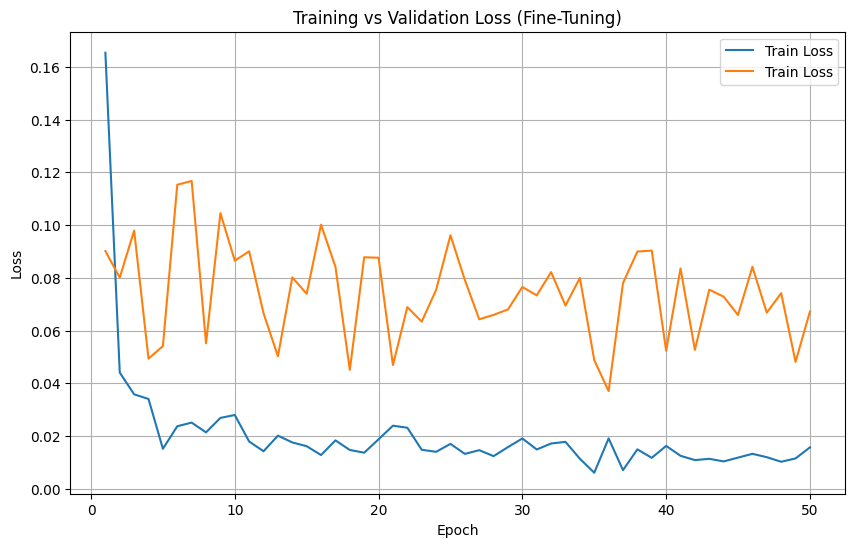

In [45]:
plt.figure(figsize=(10,6))
plt.plot(data_entrenamiento["epoch"], data_entrenamiento["train_loss"], label="Train Loss")
plt.plot(data_entrenamiento["epoch"], data_entrenamiento["val_loss"], label="Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Fine-Tuning)")
plt.legend()
plt.grid(True)
plt.show()

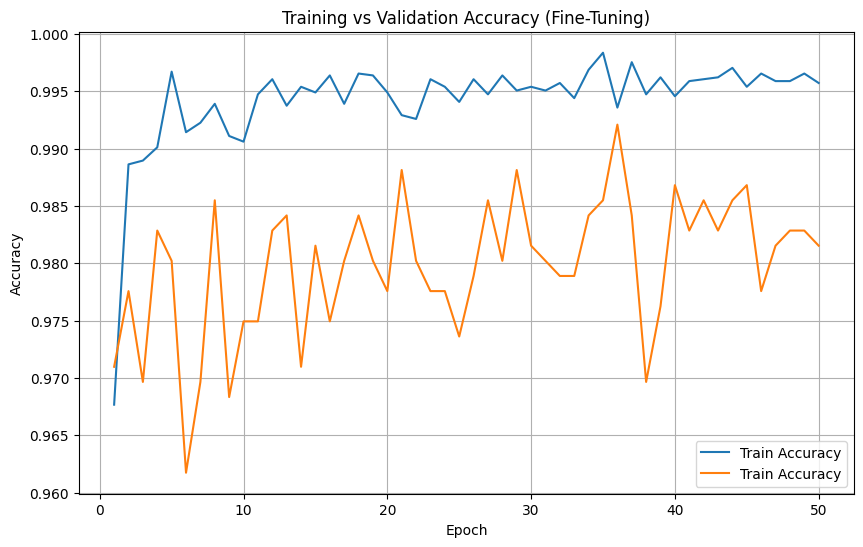

In [46]:
plt.figure(figsize=(10,6))
plt.plot(data_entrenamiento["epoch"], data_entrenamiento["train_accuracy"], label="Train Accuracy")
plt.plot(data_entrenamiento["epoch"], data_entrenamiento["val_accuracy"], label="Train Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Fine-Tuning)")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
model_path = '/content/drive/MyDrive/ProyectoDL/modelos_clasificacion_3_clases/best_vit_classifier_epoch_36/vit_classifier.pth'

model = ViTMAEForFibrosisClassification(num_labels=3, encoder=vit_mae)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

ViTMAEForFibrosisClassification(
  (encoder): ViTMAEModel(
    (embeddings): ViTMAEEmbeddings(
      (patch_embeddings): ViTMAEPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
    )
    (encoder): ViTMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTMAELayer(
          (attention): ViTMAEAttention(
            (attention): ViTMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_f

In [48]:
preds, y_true = get_predictions(model, test_loader)

Evaluando modelo:   0%|          | 0/24 [00:00<?, ?it/s]

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_true, preds, target_names=["Sano","Fibrosis Leve","Cirrosis"]))

               precision    recall  f1-score   support

         Sano       0.99      0.99      0.99       249
Fibrosis Leve       0.99      0.99      0.99       298
     Cirrosis       1.00      1.00      1.00       211

     accuracy                           0.99       758
    macro avg       0.99      0.99      0.99       758
 weighted avg       0.99      0.99      0.99       758



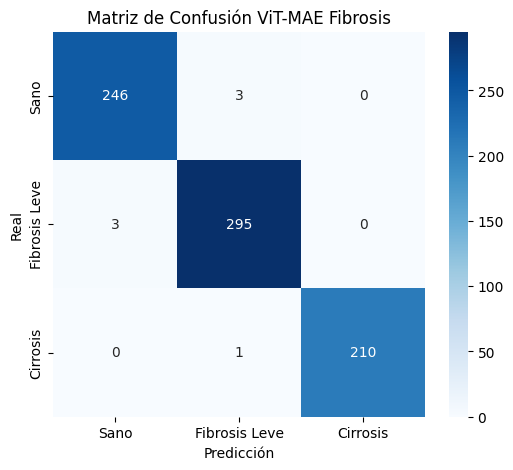

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Sano","Fibrosis Leve","Cirrosis"],
            yticklabels=["Sano","Fibrosis Leve","Cirrosis"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión ViT-MAE Fibrosis")
plt.show()

In [51]:
image_processor.save_pretrained("/content/drive/MyDrive/ProyectoDL/modelos_para_prod/artefacto_preprocessor/")

['/content/drive/MyDrive/ProyectoDL/modelos_para_prod/artefacto_preprocessor/preprocessor_config.json']

In [52]:
dummy = torch.randn(1, 3, 224, 224).to(device)
torch.onnx.export(
    model,
    dummy,
    "/content/drive/MyDrive/ProyectoDL/modelos_para_prod/3_clases.onnx",
    input_names=["pixel_values"],
    output_names=["logits"],
    dynamic_axes={
        "pixel_values": {0: "batch_size"},
        "logits": {0: "batch_size"}
    },
    opset_version=17
)


/tmp/ipython-input-4104070603.py:2: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/transformers/models/vit_mae/modeling_vit_mae.py:316: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if n